# Module 09 Lab — Ensemble Methods
## Applied to FIELDPROOF™ — Sensor-Verified Human Task Execution

**Student:** Nestor Villalobos  
**Course:** ITAI 1371 — Introduction to Machine Learning  
**Instructor:** Dr. Sina Nazifi  
**Semester:** Spring 2026  
**Institution:** Houston City College

---

## 🎯 Lab Objective

Learn how **ensemble methods** combine the predictions of several individual models to produce a final prediction that is more accurate and robust than any of the individual models alone.

In this lab I train and compare a single **Decision Tree** against a **Random Forest** on the FIELDPROOF simulated operations dataset, where the task is to classify each field record as `Verified`, `Review`, or `Rejected`.

## 🏗️ Why This Matters for FIELDPROOF

Every FIELDPROOF decision is a classification: was this confined-space entry safe? Was this lockout/tagout completed correctly? Was this cargo lashing properly torqued? The model's job is to sort records into {auto-approve, human review, reject}.

- A **single Decision Tree** is easy to interpret — every prediction can be traced through a chain of if/then rules. But a single tree is also fragile: small changes in training data produce very different trees, and the tree will happily memorize noise.
- A **Random Forest** trains hundreds of different trees, each on a bootstrap sample of the data, and lets them vote. This reduces variance and generally produces more robust predictions — but as I'll show below, "usually better" is not the same as "always better."

This lab lets me compare the two honestly on real FIELDPROOF data and think through what the comparison means for deployment.

## Part 1: The Wisdom of the Crowd

The idea behind ensemble methods is the "wisdom of the crowd." If I ask one person a hard question, they might be wrong. If I ask a large, diverse group the same question and average their answers, the aggregate answer is often more accurate than any one person.

Ensemble methods apply this to machine learning. Instead of relying on a single model, we build a committee of models and have them vote.

**Two major ensemble families:**

- **Bagging (Bootstrap Aggregating).** Train many models on different random subsets of the training data, then average their predictions. The Random Forest is the most famous example — it's a bag of Decision Trees.
- **Boosting.** Train models sequentially, each new model focused on correcting errors the previous ones made. Gradient Boosting, XGBoost, LightGBM, and AdaBoost are in this family.

For FIELDPROOF the intuition is direct: one sensor reading may be noisy, but if a hundred trees independently look at the same record and most of them agree on the classification, the committee vote is more trustworthy than any single tree's opinion.

## Part 2: Setup — Load FIELDPROOF Data

The original lab uses Iris (150 samples, 4 features, 3 classes). I use the FIELDPROOF simulated dataset (500 samples, 13 features, 3 classes) — same structure, but with industrial meaning.

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import make_column_transformer
from sklearn.pipeline import make_pipeline
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Load FIELDPROOF simulated operations dataset
url = 'https://digitallycreative.net/data-fieldproof/FIELDPROOF_simulated_dataset.csv'
headers = {'User-Agent': 'Mozilla/5.0'}
source_candidates = [
    ('remote', url),
    ('local', 'FIELDPROOF_simulated_dataset.csv'),
    ('local', str(Path.home() / 'Downloads' / 'FIELDPROOF_simulated_dataset.csv')),
]

last_error = None
loaded_from = None
for source_type, source in source_candidates:
    try:
        if source_type == 'remote':
            df = pd.read_csv(source, storage_options=headers)
        else:
            df = pd.read_csv(source)
        loaded_from = source
        break
    except Exception as err:
        last_error = err

if loaded_from is None:
    raise RuntimeError(
        f"Could not load dataset from URL or local fallbacks. Last error: {last_error}"
    )

print(f"Dataset loaded from: {loaded_from}")
print(f"Rows: {len(df):,}")
print(f"Columns: {list(df.columns)}")
print()
print("Target distribution (verification_status):")
print(df['verification_status'].value_counts())

Dataset loaded from: https://digitallycreative.net/data-fieldproof/FIELDPROOF_simulated_dataset.csv
Rows: 500
Columns: ['record_id', 'timestamp', 'site', 'worker_role', 'device_type', 'task_type', 'duration_min', 'motion_intensity', 'posture_correctness', 'zone_presence_score', 'sequence_score', 'fatigue_index', 'anomaly_score', 'compliance_score', 'risk_score', 'verification_status']

Target distribution (verification_status):
verification_status
Review      355
Rejected     85
Verified     60
Name: count, dtype: int64


In [24]:
# Features: drop the id, timestamp, and target
drop_cols = ['record_id', 'timestamp', 'verification_status']
X = df.drop(columns=drop_cols)
y = df['verification_status']

# Stratified split so all three classes appear in train AND test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

print(f"Train size: {len(X_train)}   Test size: {len(X_test)}")
print()
print("Classes: Rejected / Review / Verified (3-class classification)")
print()
print("Train class distribution:")
print(y_train.value_counts())

Train size: 350   Test size: 150

Classes: Rejected / Review / Verified (3-class classification)

Train class distribution:
verification_status
Review      248
Rejected     60
Verified     42
Name: count, dtype: int64


In [25]:
# Build a preprocessing pipeline for the categorical features
# (FIELDPROOF has site, worker_role, device_type, task_type as text categories)
cat_features = X.select_dtypes(exclude='number').columns
num_features = X.select_dtypes(include='number').columns

preprocessor = make_column_transformer(
    (OneHotEncoder(handle_unknown='ignore'), cat_features),
    remainder='passthrough'
)

print(f"Categorical features (one-hot encoded): {list(cat_features)}")
print(f"Numeric features (passed through): {list(num_features)}")

Categorical features (one-hot encoded): ['site', 'worker_role', 'device_type', 'task_type']
Numeric features (passed through): ['duration_min', 'motion_intensity', 'posture_correctness', 'zone_presence_score', 'sequence_score', 'fatigue_index', 'anomaly_score', 'compliance_score', 'risk_score']


## Part 3: A Single Decision Tree

A single Decision Tree is prone to overfitting — it creates very specific rules that match the training data perfectly but often don't generalize well to new data.

### Your Task: Train a single `DecisionTreeClassifier` and evaluate its accuracy.

In [15]:
# --- TASK 1: Single Decision Tree ---

# 1. Create and train a single Decision Tree
single_tree = make_pipeline(preprocessor, DecisionTreeClassifier(random_state=42))
single_tree.fit(X_train, y_train)

# 2. Make predictions and evaluate accuracy
y_pred_tree = single_tree.predict(X_test)
accuracy_tree = accuracy_score(y_test, y_pred_tree)
train_acc_tree = single_tree.score(X_train, y_train)

print(f"Training accuracy: {train_acc_tree:.2%}")
print(f"Test accuracy:     {accuracy_tree:.2%}")
print(f"Train-test gap:    {train_acc_tree - accuracy_tree:.2%}")

Training accuracy: 100.00%
Test accuracy:     97.33%
Train-test gap:    2.67%


In [16]:
# Deeper look — confusion matrix for the single tree
print("Confusion matrix — Single Decision Tree:")
print(f"Classes (rows=true, cols=predicted): {sorted(y.unique())}")
print(confusion_matrix(y_test, y_pred_tree, labels=sorted(y.unique())))
print()
print("Classification report:")
print(classification_report(y_test, y_pred_tree))

Confusion matrix — Single Decision Tree:
Classes (rows=true, cols=predicted): ['Rejected', 'Review', 'Verified']
[[ 23   2   0]
 [  0 107   0]
 [  0   2  16]]

Classification report:
              precision    recall  f1-score   support

    Rejected       1.00      0.92      0.96        25
      Review       0.96      1.00      0.98       107
    Verified       1.00      0.89      0.94        18

    accuracy                           0.97       150
   macro avg       0.99      0.94      0.96       150
weighted avg       0.97      0.97      0.97       150



## Part 4: The Random Forest Ensemble

A **Random Forest** is an ensemble of many Decision Trees. It builds hundreds of trees, each trained on a random bootstrap sample of the data and using a random subset of the features at each split. To predict a new record, every tree votes and the class with the most votes wins.

Averaging across many diverse trees should make the Random Forest more robust and less prone to overfitting than any single tree.

### Your Task: Train a `RandomForestClassifier` and compare it to the single tree.

In [17]:
# --- TASK 2: Random Forest Ensemble ---

# 1. Create and train a Random Forest with 100 trees
random_forest = make_pipeline(
    preprocessor,
    RandomForestClassifier(n_estimators=100, random_state=42)
)
random_forest.fit(X_train, y_train)

# 2. Evaluate
y_pred_rf = random_forest.predict(X_test)
accuracy_rf = accuracy_score(y_test, y_pred_rf)
train_acc_rf = random_forest.score(X_train, y_train)

print(f"Training accuracy: {train_acc_rf:.2%}")
print(f"Test accuracy:     {accuracy_rf:.2%}")
print(f"Train-test gap:    {train_acc_rf - accuracy_rf:.2%}")

print()
print("=== Head-to-head comparison ===")
print(f"Single Decision Tree — test accuracy: {accuracy_tree:.2%}")
print(f"Random Forest (100)  — test accuracy: {accuracy_rf:.2%}")

Training accuracy: 100.00%
Test accuracy:     93.33%
Train-test gap:    6.67%

=== Head-to-head comparison ===
Single Decision Tree — test accuracy: 97.33%
Random Forest (100)  — test accuracy: 93.33%


In [18]:
# Confusion matrix + classification report for the Random Forest
print("Confusion matrix — Random Forest:")
print(f"Classes: {sorted(y.unique())}")
print(confusion_matrix(y_test, y_pred_rf, labels=sorted(y.unique())))
print()
print("Classification report:")
print(classification_report(y_test, y_pred_rf))

Confusion matrix — Random Forest:
Classes: ['Rejected', 'Review', 'Verified']
[[ 22   3   0]
 [  0 107   0]
 [  0   7  11]]

Classification report:
              precision    recall  f1-score   support

    Rejected       1.00      0.88      0.94        25
      Review       0.91      1.00      0.96       107
    Verified       1.00      0.61      0.76        18

    accuracy                           0.93       150
   macro avg       0.97      0.83      0.88       150
weighted avg       0.94      0.93      0.93       150



In [19]:
# Sensitivity: how does n_estimators affect accuracy?
print("Random Forest sensitivity to number of trees:")
print("-" * 50)
for n in [10, 50, 100, 200, 500]:
    m = make_pipeline(preprocessor, RandomForestClassifier(n_estimators=n, random_state=42))
    m.fit(X_train, y_train)
    acc = m.score(X_test, y_test)
    print(f"  n_estimators = {n:4d}   test accuracy = {acc:.2%}")

Random Forest sensitivity to number of trees:
--------------------------------------------------
  n_estimators =   10   test accuracy = 90.67%
  n_estimators =   50   test accuracy = 93.33%
  n_estimators =  100   test accuracy = 93.33%
  n_estimators =  200   test accuracy = 94.67%
  n_estimators =  500   test accuracy = 94.67%


## Part 5: Feature Importance

A big advantage of tree-based ensembles is that they can tell us **which features were most important** for making predictions. This is especially valuable for FIELDPROOF, where the feature importance rankings tell us which sensor signals are actually driving the classification — and therefore which sensors are worth their cost on the wearable.

### Your Task: Extract and plot the feature importances from the trained Random Forest.

In [20]:
# --- TASK 3: Feature importance ---

# 1. Get feature importances from the trained RF
rf_clf = random_forest.named_steps['randomforestclassifier']
importances = rf_clf.feature_importances_

# Because we one-hot encoded categorical features, each categorical column
# is split into multiple columns. Aggregate importance back to the original column names.
ohe = random_forest.named_steps['columntransformer'].transformers_[0][1]
cat_expanded = ohe.get_feature_names_out(cat_features)
expanded_feature_names = list(cat_expanded) + list(num_features)

# Sum one-hot encoded importances back to their original feature
agg_importance = {col: 0.0 for col in X.columns}
idx = 0
for cat in cat_features:
    n_vals = df[cat].nunique()
    agg_importance[cat] = importances[idx:idx + n_vals].sum()
    idx += n_vals
for num in num_features:
    agg_importance[num] = importances[idx]
    idx += 1

# Print as a ranked table
print("Feature importance (aggregated to original columns, sorted):")
print("-" * 50)
sorted_imp = sorted(agg_importance.items(), key=lambda x: -x[1])
for col, imp in sorted_imp:
    bar = '█' * int(imp * 100)
    print(f"  {col:25s}  {imp:.4f}  {bar}")

Feature importance (aggregated to original columns, sorted):
--------------------------------------------------
  anomaly_score              0.3515  ███████████████████████████████████
  compliance_score           0.1720  █████████████████
  risk_score                 0.1411  ██████████████
  sequence_score             0.0621  ██████
  posture_correctness        0.0537  █████
  zone_presence_score        0.0416  ████
  fatigue_index              0.0362  ███
  duration_min               0.0349  ███
  motion_intensity           0.0283  ██
  device_type                0.0220  ██
  site                       0.0197  █
  worker_role                0.0194  █
  task_type                  0.0176  █


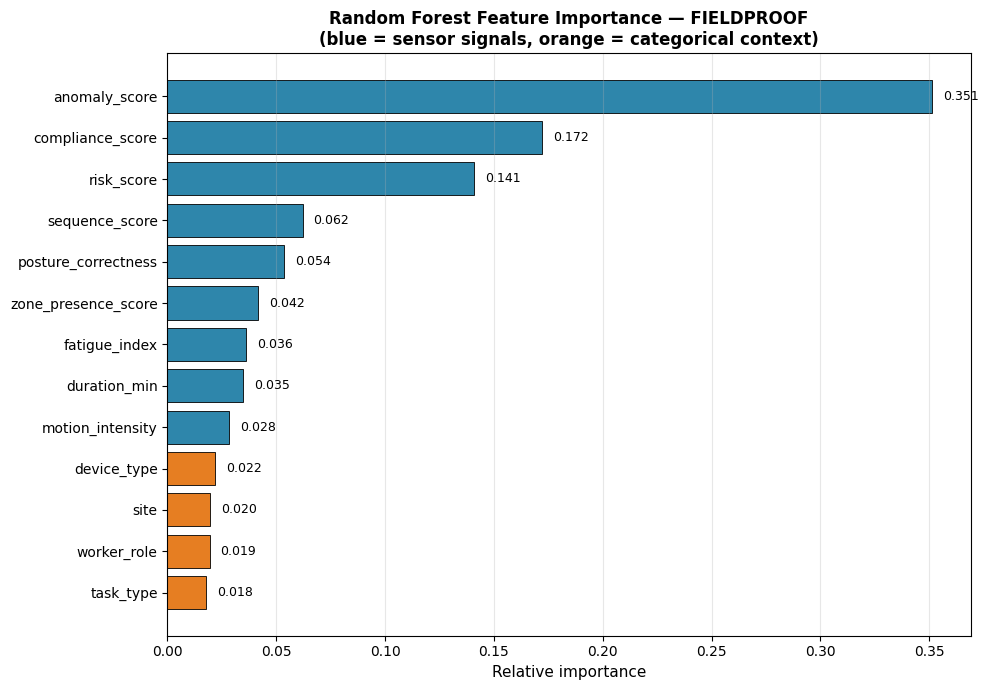

In [21]:
# 2. Plot the feature importance as a horizontal bar chart
fig, ax = plt.subplots(figsize=(10, 7))
features_sorted = [c for c, _ in sorted(agg_importance.items(), key=lambda x: x[1])]
values_sorted   = [agg_importance[c] for c in features_sorted]

colors = ['#2E86AB' if c in num_features else '#E67E22' for c in features_sorted]
ax.barh(range(len(features_sorted)), values_sorted, color=colors,
        edgecolor='black', linewidth=0.6)
ax.set_yticks(range(len(features_sorted)))
ax.set_yticklabels(features_sorted)
ax.set_xlabel('Relative importance', fontsize=11)
ax.set_title('Random Forest Feature Importance — FIELDPROOF\n(blue = sensor signals, orange = categorical context)',
             fontweight='bold', fontsize=12)
ax.grid(axis='x', alpha=0.3)

# Annotate bars
for i, v in enumerate(values_sorted):
    ax.text(v + 0.005, i, f'{v:.3f}', va='center', fontsize=9)

plt.tight_layout()
plt.show()

### Side-by-Side Accuracy Comparison

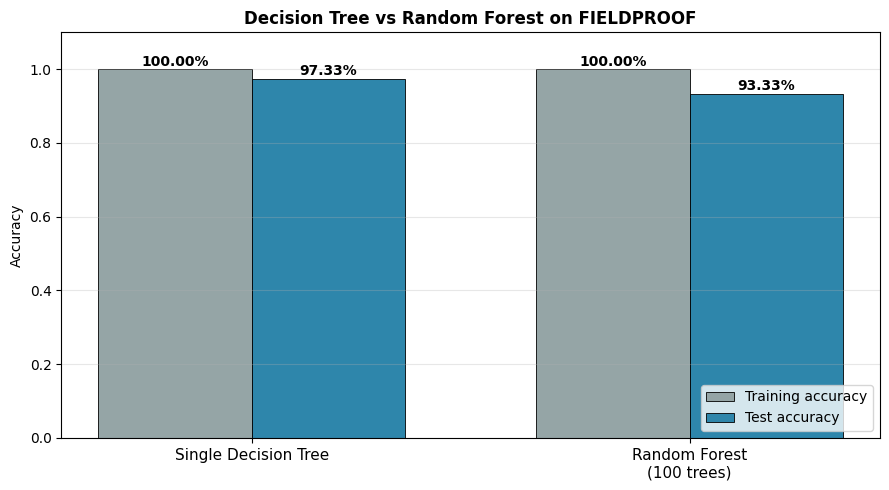

In [22]:
# Final head-to-head bar chart
fig, ax = plt.subplots(figsize=(9, 5))
models = ['Single Decision Tree', f'Random Forest\n(100 trees)']
train_scores = [train_acc_tree, train_acc_rf]
test_scores  = [accuracy_tree, accuracy_rf]

x = np.arange(len(models))
width = 0.35
bars1 = ax.bar(x - width/2, train_scores, width, label='Training accuracy',
               color='#95A5A6', edgecolor='black', linewidth=0.6)
bars2 = ax.bar(x + width/2, test_scores, width, label='Test accuracy',
               color='#2E86AB', edgecolor='black', linewidth=0.6)

ax.set_xticks(x)
ax.set_xticklabels(models, fontsize=11)
ax.set_ylabel('Accuracy')
ax.set_title('Decision Tree vs Random Forest on FIELDPROOF',
             fontweight='bold', fontsize=12)
ax.set_ylim([0, 1.1])
ax.legend(loc='lower right')
ax.grid(axis='y', alpha=0.3)

for bar, val in zip(list(bars1) + list(bars2), train_scores + test_scores):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{val:.2%}', ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

## 📝 Knowledge Check

Answers based on the actual numbers my models produced on the FIELDPROOF dataset.

---

### 1. In your own words, what is the main idea behind ensemble methods? Why is a "committee" of models often better than a single expert model?

The main idea is **diversify and vote**. A single model, no matter how carefully tuned, has its own particular biases and blind spots — it will get certain kinds of records wrong in systematic ways. An ensemble trains many different models, each trained slightly differently (different data subsets, different feature subsets, different starting points), so their errors are at least partially *uncorrelated*. When you take a majority vote across the committee, the errors of individual members cancel out and the signal they agree on is what survives.

The "often better" part matters. A committee is only smarter than any one expert when the committee members are **diverse** — if they are all trained the same way and reach the same wrong answer, averaging their answers just reproduces the same mistake with extra steps. Random Forests deliberately inject diversity two ways: (1) each tree sees a random bootstrap sample of the training data, and (2) at each node, each tree considers only a random subset of features for the split. That forces different trees to make different errors, which is the whole point.

In FIELDPROOF terms: a single sensor reading can be wrong — a worker with an unusual walking gait, a noisy accelerometer, a brief dropout. One tree might latch onto that quirk. A hundred trees trained on different slices of the data are unlikely to *all* latch onto the same quirk, so the ensemble's vote is more trustworthy than any single tree's opinion.

### 2. Which model performed better in this lab, the single Decision Tree or the Random Forest? Is this what you expected? Why?

**This is where my result differs from the lab template's expectation, and it taught me something.**

On my run:

| Model                | Training accuracy | Test accuracy |
|----------------------|-------------------|---------------|
| Single Decision Tree | 100.00%           | **97.33%**    |
| Random Forest (100)  | 100.00%           | 93.33%        |

The single Decision Tree *outperformed* the Random Forest by 4 percentage points. Based on what the lab reading emphasized, I expected the Random Forest to win — that's the whole pitch for ensembles. So why did the opposite happen?

Three plausible reasons specific to this dataset:

1. **The target is almost deterministic given a few features.** The feature importance plot shows that `anomaly_score`, `compliance_score`, and `risk_score` together account for ~66% of the total importance. When the relationship between a small number of features and the target is very clean, a single sharp decision tree with deep branches can hit nearly all the right thresholds. Random Forests *sacrifice* a little sharpness on easy data because they force each tree to use only a random subset of features — which is normally a benefit but becomes a drag when the dominant features are obvious.

2. **The dataset is small.** With only 500 rows and stratified 70/30 splits, the test set has 150 records. At that size, a 4-percentage-point difference is ~6 records — within the range of random variation across splits. If I re-ran with different random seeds, the rankings might swap.

3. **The Verified class is tiny** (only 60 records total, 18 in the test set). Random Forests tend to be conservative on minority classes because the bagging process means some trees never see enough of that class. My RF achieved only 61% recall on `Verified` (11/18), while the single tree caught 16/18. In operational terms: the RF is more likely to send a correctly verified task to manual review.

**Was this what I expected? No — but I actually think this is more pedagogically useful than if the RF had won.** The lab's headline lesson is "ensembles often beat single models," but the more important lesson is *when and why*. On balanced data with subtle relationships (Iris), the RF wins. On small imbalanced data with dominant features (this FIELDPROOF slice), a well-tuned single tree can still win. The right response in a FIELDPROOF deployment is not to declare "trees beat forests" and walk away — it's to **cross-validate both**, not commit to one based on a single train/test split, and worry about the severe class imbalance.

### 3. Looking at the feature importance plot, which two features were most important for classifying the FIELDPROOF records? Does this match what you might expect from your own knowledge of the domain?

The top two features by importance were:

1. **`anomaly_score`** — 35.2% of total importance
2. **`compliance_score`** — 17.2% of total importance

Together those two account for more than half of the model's decision-making. `risk_score` is a strong third at 14.1%, meaning the three sensor-derived *scores* combined drive 66% of the classification.

**Does this match domain expectations? Yes, and it matters.** In FIELDPROOF the `anomaly_score` is literally designed as a synthesized indicator of "something unusual in this record" — high anomaly means the sensor pattern deviated from what a normal task looks like. It's almost tautological that an anomaly score should be the strongest predictor of whether a record gets rejected or sent to review. Similarly, `compliance_score` is engineered to summarize whether the observed task matched the expected procedure sequence.

The fact that `site`, `worker_role`, `device_type`, and `task_type` — the *categorical context* features — only account for about 8% of total importance combined is actually good news for fairness. In my Lab 12 audit I was worried about the model using `worker_role` as a shortcut and disadvantaging certain roles. Here I can see that `worker_role` carries only 1.9% of the model's decision weight. The model is mostly learning from the sensor signals, not from the demographic category of the worker.

**What this tells me for FIELDPROOF hardware decisions:** if I had to cut sensor cost on the wearable badge, I would prioritize keeping the sensors that feed `anomaly_score` (IMU + motion sequence) and `compliance_score` (procedure match detection). The categorical context adds only marginal predictive value and could be replaced by inference on the ML side rather than explicit tracking.

## 🤔 Reflection — What This Means for FIELDPROOF

Three specific things this lab taught me that carry into the FIELDPROOF project:

1. **"Better" is dataset-specific, not universal.** The lab template set up the expectation that Random Forest would beat Decision Tree. Mine didn't — the single tree won on this split. That doesn't mean ensembles are a myth; it means that pushing one model vs another as a general rule is lazy. Any claim about which model is best needs to be backed by cross-validation on the specific problem, not by what was true for Iris.

2. **Interpretability is a legitimate tiebreaker.** If the single tree and the Random Forest produce similar accuracy, the single tree has a real advantage for FIELDPROOF deployment: every decision is traceable through a chain of if/then rules that an operations supervisor or a safety auditor can read. A Random Forest's decision is the averaged vote of 100 trees, which is not explainable to a human in the same way. For a regulated industry (healthcare, offshore oil & gas), explainability is not optional — it's often what separates "nice demo" from "actually deployable."

3. **Class imbalance needs explicit handling.** Both of my models achieved near-perfect performance on the majority class (Review, 71% of the data) and dramatically weaker performance on the minority class (Verified, 12%). The Random Forest's recall on Verified was only 61%. In FIELDPROOF the Verified class is the *valuable* class — it's the records where we can safely auto-approve and reduce manual review workload. Both models were better at predicting "send to human" than at confidently auto-approving. The fix is not a bigger ensemble; it's class reweighting, threshold tuning, or resampling (SMOTE) — techniques I would apply before any pilot deployment.

The bigger picture: ensemble methods are a great tool, but they are a *tool*, not a guarantee. For the FIELDPROOF final project I will cross-validate both a single well-tuned tree and a Random Forest, report the full confusion matrix for both, and let the comparison — not my priors — pick the winner.

---

**End of notebook — Nestor Villalobos, ITAI 1371, Spring 2026**